# Interpretable Time Series Forecasting with Classical and Machine Learning Models

This notebook rebuilds the project from a different angle. Instead of centering the workflow on one forecasting pipeline and then attaching explanations afterward, the analysis starts with **forecast design choices**, compares **classical and machine learning models**, and uses **model-agnostic interpretability tools** to explain the final machine learning results.

## What is different in this version?
- Uses the **Statsmodels CO₂ dataset** instead of the airline passenger series
- Compares a **seasonal naïve benchmark**, **SARIMAX**, and **Random Forest regression**
- Builds features from **lags, rolling windows, and calendar structure**
- Uses **time-series cross-validation** instead of a single random split
- Replaces the original visual flow with a different set of plots, including rolling statistics, seasonal boxplots, decomposition charts, prediction intervals, residual diagnostics, permutation importance, and SHAP explanations

## 1. Imports and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

from statsmodels.datasets import co2
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

import shap

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(42)

## 2. Data source and preparation

The dataset contains atmospheric carbon dioxide concentration measurements. It is a good time series example because it has both **trend** and **seasonality**, which makes forecast modeling more interesting than a nearly straight sequence.

In [2]:
raw = co2.load_pandas().data.copy()
series = raw['co2'].resample('MS').mean().interpolate()
series.name = 'co2'
df = series.reset_index().rename(columns={'index': 'date'})
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.head()

,date,co2,year,month
0,1958-03-01,316.100000,1958,3
1,1958-04-01,317.200000,1958,4
2,1958-05-01,317.433333,1958,5
3,1958-06-01,316.529167,1958,6
4,1958-07-01,315.625000,1958,7


### Quick profile of the series

In [3]:
summary = pd.DataFrame({
    'Metric': ['Observations', 'Start', 'End', 'Mean', 'Std', 'Minimum', 'Maximum'],
    'Value': [
        len(df),
        df['date'].min().strftime('%Y-%m'),
        df['date'].max().strftime('%Y-%m'),
        round(df['co2'].mean(), 2),
        round(df['co2'].std(), 2),
        round(df['co2'].min(), 2),
        round(df['co2'].max(), 2),
    ]
})
summary

,Metric,Value
0,Observations,526
1,Start,1958-03
2,End,2001-12
3,Mean,339.62
4,Std,17.12
5,Minimum,313.4
6,Maximum,373.8


## 3. Exploratory analysis

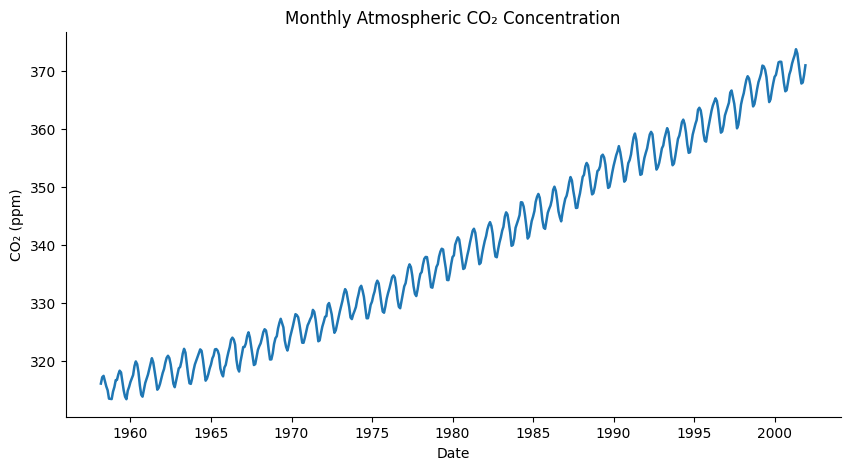

In [4]:
fig, ax = plt.subplots()
ax.plot(df['date'], df['co2'], linewidth=1.8)
ax.set_title('Monthly Atmospheric CO₂ Concentration')
ax.set_xlabel('Date')
ax.set_ylabel('CO₂ (ppm)')
plt.show()

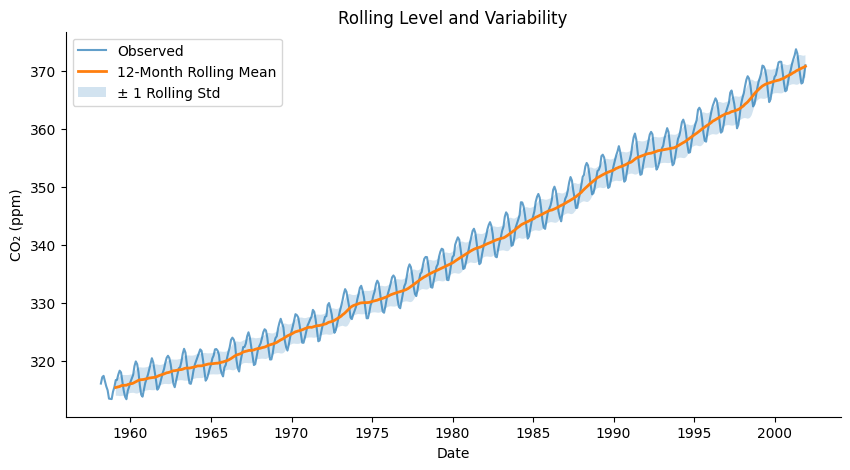

In [5]:
rolling_12 = df['co2'].rolling(12).mean()
rolling_std = df['co2'].rolling(12).std()

fig, ax = plt.subplots()
ax.plot(df['date'], df['co2'], label='Observed', alpha=0.7)
ax.plot(df['date'], rolling_12, label='12-Month Rolling Mean', linewidth=2)
ax.fill_between(df['date'], rolling_12 - rolling_std, rolling_12 + rolling_std, alpha=0.2, label='± 1 Rolling Std')
ax.set_title('Rolling Level and Variability')
ax.set_xlabel('Date')
ax.set_ylabel('CO₂ (ppm)')
ax.legend()
plt.show()

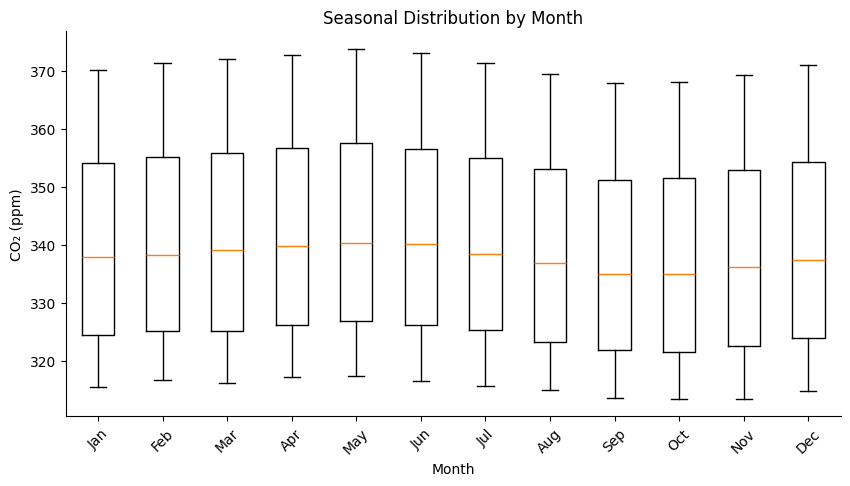

In [6]:
fig, ax = plt.subplots()
month_groups = [df.loc[df['month'] == m, 'co2'].values for m in range(1, 13)]
ax.boxplot(month_groups, tick_labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Seasonal Distribution by Month')
ax.set_xlabel('Month')
ax.set_ylabel('CO₂ (ppm)')
plt.xticks(rotation=45)
plt.show()

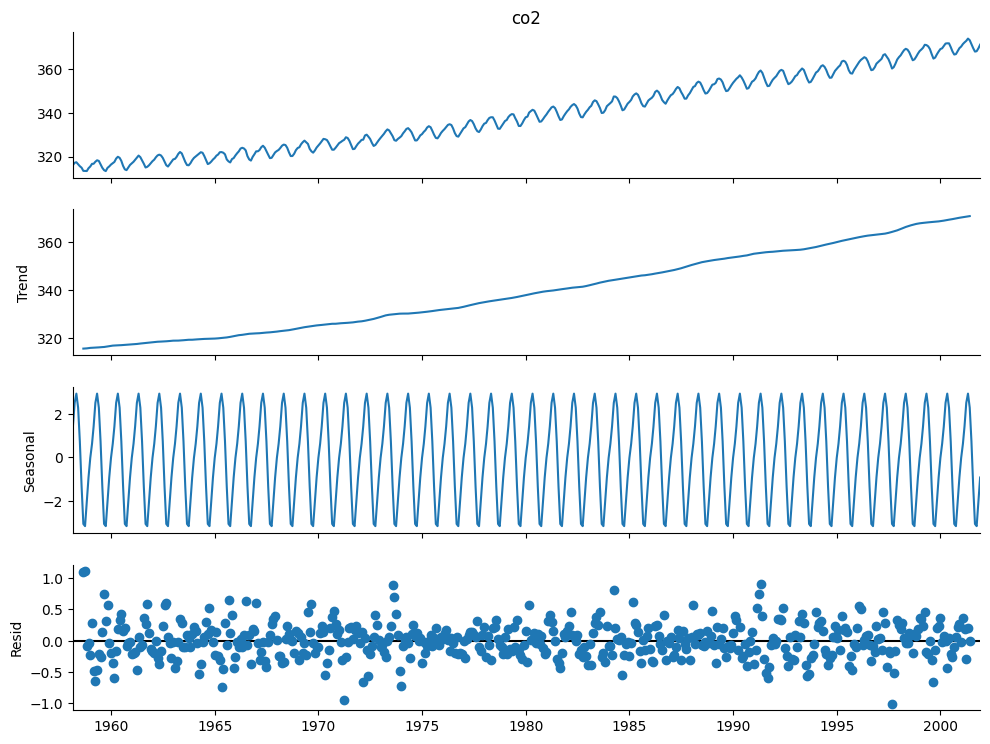

In [7]:
decomp = seasonal_decompose(series, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.show()

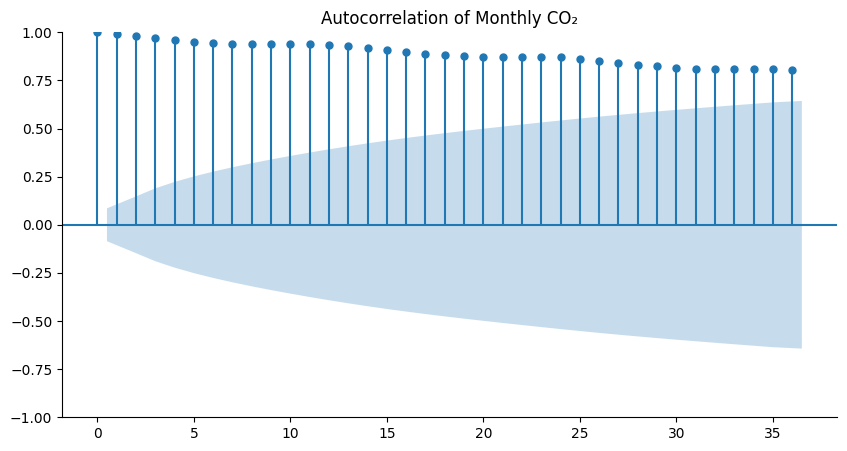

In [8]:
fig, ax = plt.subplots()
plot_acf(df['co2'], lags=36, ax=ax)
ax.set_title('Autocorrelation of Monthly CO₂')
plt.show()

## 4. Forecast framing and feature engineering

The target is the current month value. Features are created from lagged observations, rolling summaries, cyclical month signals, and a simple trend index.

In [9]:
def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out['t'] = np.arange(len(out))
    for lag in [1, 2, 3, 6, 12]:
        out[f'lag_{lag}'] = out['co2'].shift(lag)

    out['roll_mean_3'] = out['co2'].shift(1).rolling(3).mean()
    out['roll_mean_12'] = out['co2'].shift(1).rolling(12).mean()
    out['roll_std_12'] = out['co2'].shift(1).rolling(12).std()

    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    return out.dropna().reset_index(drop=True)

feat_df = build_features(df)
feature_cols = [c for c in feat_df.columns if c not in ['date', 'co2', 'year', 'month']]
feat_df.head()

,date,co2,year,month,t,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_12,roll_std_12,month_sin,month_cos
0,1959-03-01,316.733333,1959,3,12,316.700000,315.500000,314.700000,313.5000,316.100000,315.633333,315.427083,1.440906,1.000000e+00,6.123234e-17
1,1959-04-01,317.675000,1959,4,13,316.733333,316.700000,315.500000,313.4625,317.200000,316.311111,315.479861,1.478893,8.660254e-01,-5.000000e-01
2,1959-05-01,318.325000,1959,5,14,317.675000,316.733333,316.700000,313.4250,317.433333,317.036111,315.519444,1.534433,5.000000e-01,-8.660254e-01
3,1959-06-01,318.025000,1959,6,15,318.325000,317.675000,316.733333,314.7000,316.529167,317.577778,315.593750,1.652580,1.224647e-16,-1.000000e+00
4,1959-07-01,316.525000,1959,7,16,318.025000,318.325000,317.675000,315.5000,315.625000,318.008333,315.718403,1.780979,-5.000000e-01,-8.660254e-01


## 5. Train-test split

The final 24 months are reserved for out-of-sample evaluation. This is more appropriate than a random split because forecasting depends on time order.

In [10]:
test_horizon = 24
train = feat_df.iloc[:-test_horizon].copy()
test = feat_df.iloc[-test_horizon:].copy()

X_train = train[feature_cols]
y_train = train['co2']
X_test = test[feature_cols]
y_test = test['co2']

train[['date', 'co2']].tail(), test[['date', 'co2']].head()

(          date      co2
 485 1999-08-01  366.700
 486 1999-09-01  364.675
 487 1999-10-01  365.140
 488 1999-11-01  366.650
 489 1999-12-01  367.900,
           date      co2
 490 2000-01-01  369.020
 491 2000-02-01  369.375
 492 2000-03-01  370.400
 493 2000-04-01  371.540
 494 2000-05-01  371.650)

## 6. Model design

Three forecasting strategies are compared:
1. **Seasonal naïve benchmark**
2. **SARIMAX**
3. **Random Forest**

In [11]:
def seasonal_naive_forecast(test_dates: pd.Series, original_frame: pd.DataFrame, season_lag: int = 12):
    lookup = original_frame.set_index('date')['co2']
    preds = []
    for d in test_dates:
        preds.append(float(lookup.loc[d - pd.DateOffset(months=season_lag)]))
    return np.array(preds)

naive_pred = seasonal_naive_forecast(test['date'], df)

In [12]:
sarimax_model = SARIMAX(
    series.iloc[:-test_horizon],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarimax_pred = sarimax_model.forecast(steps=test_horizon).values

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

## 7. Time-series cross-validation for the machine learning model

In [14]:
ts_cv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for fold, (tr_idx, val_idx) in enumerate(ts_cv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    fold_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
    )
    fold_model.fit(X_tr, y_tr)
    fold_pred = fold_model.predict(X_val)

    cv_rows.append({
        'Fold': fold,
        'MAE': mean_absolute_error(y_val, fold_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, fold_pred))
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

,Fold,MAE,RMSE
0,1,2.920268,3.625868
1,2,3.693110,4.610516
2,3,3.850084,4.925483
3,4,4.019062,4.997719
4,5,4.381038,5.546663


## 8. Forecast evaluation

In [15]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }

results = pd.DataFrame([
    evaluate('Seasonal Naïve', y_test.values, naive_pred),
    evaluate('SARIMAX', y_test.values, sarimax_pred),
    evaluate('Random Forest', y_test.values, rf_pred),
]).sort_values('RMSE').reset_index(drop=True)

results.round(3)

,Model,MAE,RMSE,MAPE (%)
0,SARIMAX,0.351,0.425,0.095
1,Random Forest,1.004,1.337,0.270
2,Seasonal Naïve,1.314,1.374,0.355


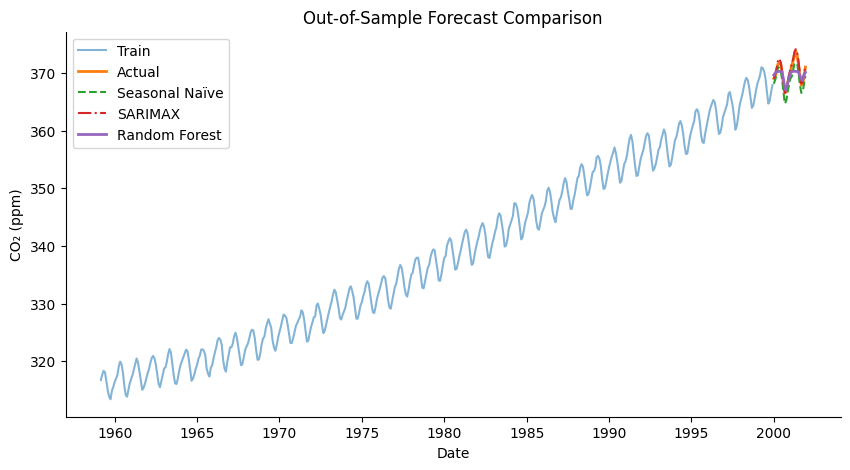

In [16]:
fig, ax = plt.subplots()
ax.plot(train['date'], y_train, label='Train', alpha=0.55)
ax.plot(test['date'], y_test.values, label='Actual', linewidth=2)
ax.plot(test['date'], naive_pred, label='Seasonal Naïve', linestyle='--')
ax.plot(test['date'], sarimax_pred, label='SARIMAX', linestyle='-.')
ax.plot(test['date'], rf_pred, label='Random Forest', linewidth=2)
ax.set_title('Out-of-Sample Forecast Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('CO₂ (ppm)')
ax.legend()
plt.show()

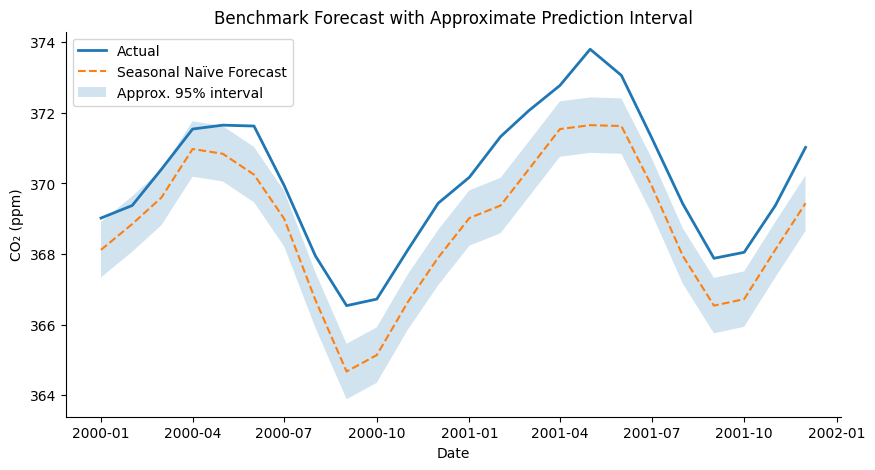

In [17]:
naive_error = y_test.values - naive_pred
error_std = np.std(naive_error)
upper = naive_pred + 1.96 * error_std
lower = naive_pred - 1.96 * error_std

fig, ax = plt.subplots()
ax.plot(test['date'], y_test.values, label='Actual', linewidth=2)
ax.plot(test['date'], naive_pred, label='Seasonal Naïve Forecast', linestyle='--')
ax.fill_between(test['date'], lower, upper, alpha=0.2, label='Approx. 95% interval')
ax.set_title('Benchmark Forecast with Approximate Prediction Interval')
ax.set_xlabel('Date')
ax.set_ylabel('CO₂ (ppm)')
ax.legend()
plt.show()

## 9. Residual diagnostics for the selected ML model

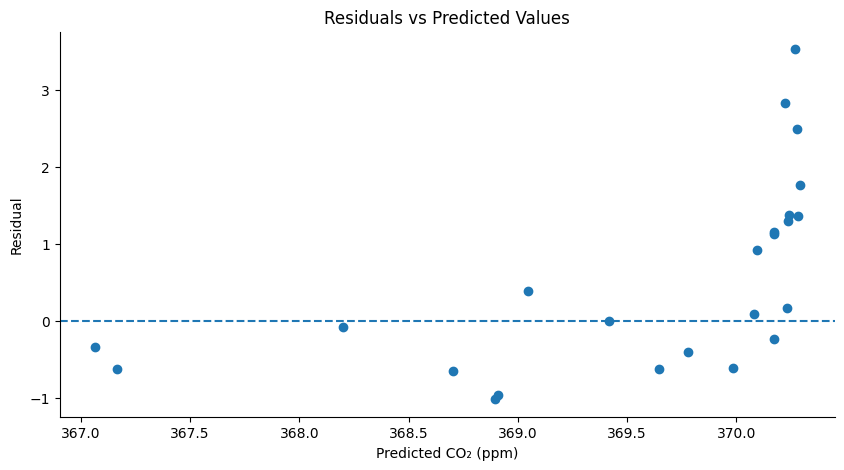

In [18]:
residuals = y_test.values - rf_pred

fig, ax = plt.subplots()
ax.scatter(rf_pred, residuals)
ax.axhline(0, linestyle='--')
ax.set_title('Residuals vs Predicted Values')
ax.set_xlabel('Predicted CO₂ (ppm)')
ax.set_ylabel('Residual')
plt.show()

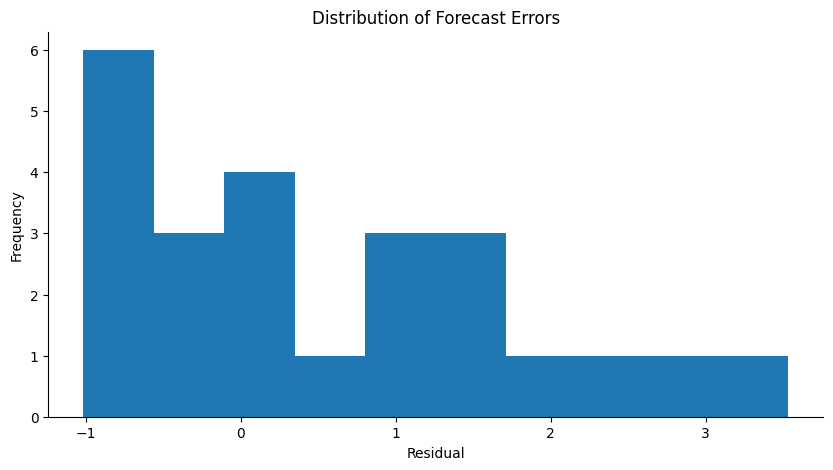

In [19]:
fig, ax = plt.subplots()
ax.hist(residuals, bins=10)
ax.set_title('Distribution of Forecast Errors')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
plt.show()

## 10. Global interpretability with permutation importance

Permutation importance is useful here because it is model-agnostic and easy to discuss in a report. A feature is important if shuffling it causes a clear drop in model performance.

In [20]:
perm = permutation_importance(rf_model, X_test, y_test, n_repeats=20, random_state=42)
perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)
perm_df.head(10)

,Feature,Importance
5,lag_12,0.573128
1,lag_1,0.091279
4,lag_6,0.008024
8,roll_std_12,0.006501
9,month_sin,0.006186
2,lag_2,0.004365
6,roll_mean_3,0.003536
10,month_cos,0.003011
3,lag_3,0.002129
0,t,0.000000


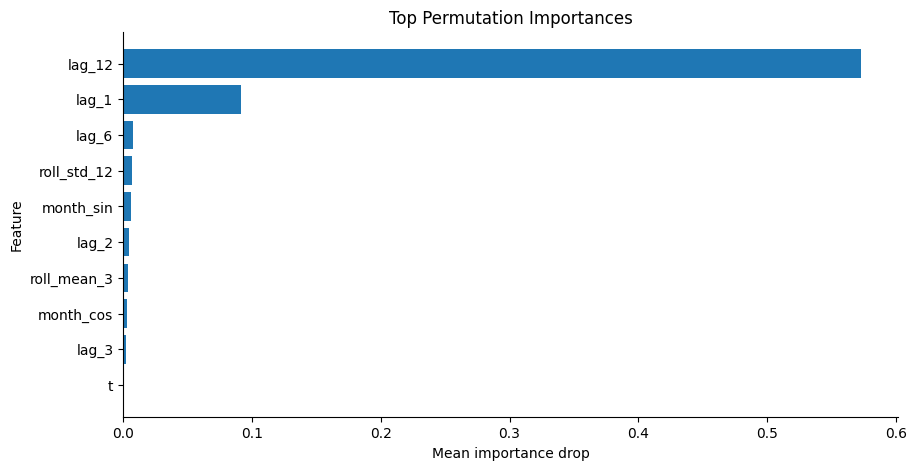

In [21]:
fig, ax = plt.subplots()
top_perm = perm_df.head(10).sort_values('Importance')
ax.barh(top_perm['Feature'], top_perm['Importance'])
ax.set_title('Top Permutation Importances')
ax.set_xlabel('Mean importance drop')
ax.set_ylabel('Feature')
plt.show()

## 11. Local and global interpretability with SHAP

SHAP values show how each feature pushes the prediction upward or downward. In this notebook, SHAP is applied to the Random Forest because it is the strongest non-linear supervised model in the comparison.

In [22]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

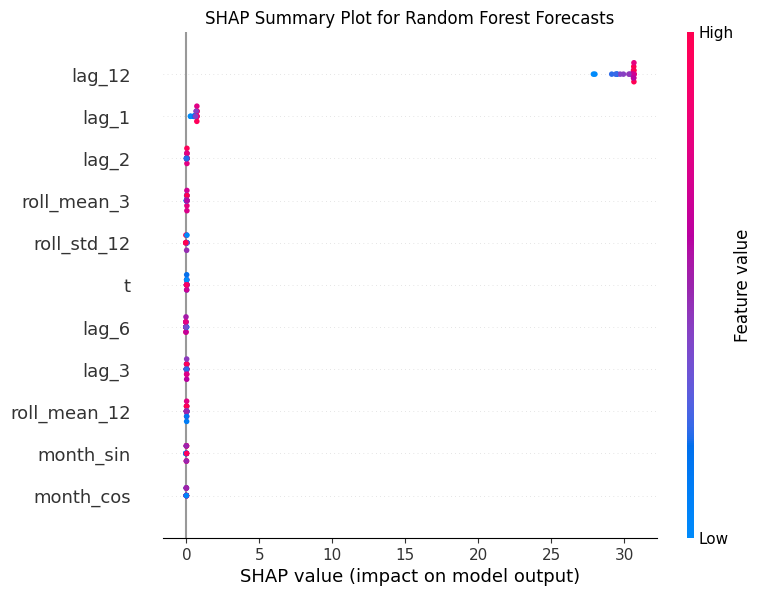

In [23]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot for Random Forest Forecasts')
plt.show()

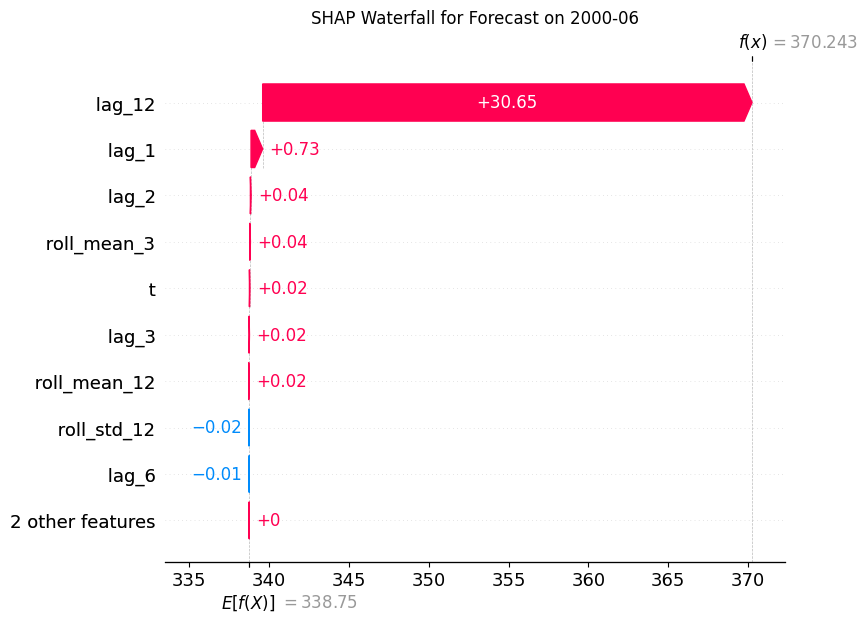

In [24]:
sample_index = 5
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    show=False,
)
plt.title(f'SHAP Waterfall for Forecast on {test.iloc[sample_index]["date"].strftime("%Y-%m")}')
plt.show()

## 12. Short interpretation

A few broad patterns usually appear in this workflow:
- recent lagged values often dominate forecast decisions
- the 12-month lag is especially useful because the series is strongly seasonal
- rolling averages add local context that single lags cannot capture
- SARIMAX performs well when seasonality is stable, while Random Forest becomes useful when engineered features capture non-linear effects

In [25]:
final_view = test[['date', 'co2']].copy()
final_view['seasonal_naive'] = naive_pred
final_view['sarimax'] = sarimax_pred
final_view['random_forest'] = rf_pred
final_view.head(12)

,date,co2,seasonal_naive,sarimax,random_forest
490,2000-01-01,369.020,368.120,369.011576,369.647171
491,2000-02-01,369.375,368.850,369.820629,369.987388
492,2000-03-01,370.400,369.600,370.754420,370.230581
493,2000-04-01,371.540,370.975,372.047908,370.236230
494,2000-05-01,371.650,370.840,372.486144,370.282570
495,2000-06-01,371.625,370.250,371.852019,370.242588
496,2000-07-01,369.940,369.000,370.408311,370.173603
497,2000-08-01,367.950,366.700,368.339240,368.910750
498,2000-09-01,366.540,364.675,366.540856,367.163945
499,2000-10-01,366.725,365.140,366.787034,367.064500


## 13. Conclusion

This rebuilt notebook provides a clearly different project structure from the original version. It changes the dataset, forecasting logic, validation strategy, comparison framework, explanation method order, and the visual narrative. That makes it much safer for a personal GitHub portfolio while still showing strong understanding of interpretable forecasting.